In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
import warnings
warnings.filterwarnings('ignore')

In [3]:
orders = pd.read_csv('orders.csv')
products = pd.read_csv('products.csv')
aisles = pd.read_csv('aisles.csv')
order_products_train = pd.read_csv('/content/order_products__train.csv')
order_products_prior = pd.read_csv('/content/order_products__prior.csv')

In [5]:
print("Volume of data before preprocessing")

Volume of data before preprocessing


In [6]:
print(f"orders: {orders.shape}")
print(f"products: {products.shape}")
print(f"order_products: {order_products_all.shape}")

orders: (3421083, 7)
products: (49688, 4)
order_products: (33819106, 4)


In [4]:
import pandas as pd
from mlxtend.preprocessing import TransactionEncoder

**Load only needed columns**

In [5]:
orders = pd.read_csv("orders.csv", usecols=['order_id'])

order_products = pd.read_csv(
    "order_products__prior.csv",
    usecols=['order_id', 'product_id']
)

products = pd.read_csv(
    "products.csv",
    usecols=['product_id', 'aisle_id']
)

aisles = pd.read_csv("aisles.csv")

**Create Mapping instead of Merge**

In [6]:
product_to_aisle = dict(zip(products.product_id, products.aisle_id))
aisle_id_to_name = dict(zip(aisles.aisle_id, aisles.aisle))

**Preserve only Important columns**

In [7]:
order_products['aisle_id'] = order_products['product_id'].map(product_to_aisle)
order_products['aisle'] = order_products['aisle_id'].map(aisle_id_to_name)


order_products = order_products[['order_id', 'aisle']]

In [10]:
order_products.isna().sum()

,0
order_id,0
aisle,0


**Choose Sample**

In [11]:
order_products = order_products.sample(100000)

**Create Transactions**

In [12]:
transactions = order_products.groupby('order_id')['aisle'].apply(list)
transactions = transactions[transactions.apply(len) > 1]

**Convert to List of Lists**

In [13]:
transactions_list = transactions.tolist()

**One-hot Encoding (FP_growth)**

In [14]:
te = TransactionEncoder()
te_array = te.fit(transactions_list).transform(transactions_list)

df_encoded = pd.DataFrame(te_array, columns=te.columns_)

In [15]:
print(df_encoded.shape)
df_encoded.head()

(2141, 126)


,air fresheners candles,asian foods,baby accessories,baby bath body care,baby food formula,bakery desserts,baking ingredients,baking supplies decor,beers coolers,body lotions soap,...,spreads,tea,tofu meat alternatives,tortillas flat bread,trail mix snack mix,trash bags liners,vitamins supplements,water seltzer sparkling water,white wines,yogurt
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [17]:

import pandas as pd
import numpy as np

orders = pd.read_csv('orders.csv', usecols=['order_id', 'user_id', 'order_dow',
                                             'order_hour_of_day', 'days_since_prior_order',
                                             'order_number', 'eval_set'])
products = pd.read_csv('products.csv', usecols=['product_id', 'aisle_id'])
aisles = pd.read_csv('aisles.csv')
order_products_prior = pd.read_csv('order_products__prior.csv', nrows=5000000)  # 5M فقط


merged = order_products_prior.merge(products, on='product_id', how='inner')
final_df = merged.merge(orders, on='order_id', how='inner')


final_df = final_df.drop(columns=['eval_set'])


final_df['days_since_prior_order'] = final_df['days_since_prior_order'].fillna(0)


for col in ['order_number', 'days_since_prior_order', 'add_to_cart_order']:
    final_df[col] = (final_df[col] - final_df[col].min()) / (final_df[col].max() - final_df[col].min())

aisle_patterns = final_df.merge(aisles, on='aisle_id')['aisle'].value_counts().head(10)
print(aisle_patterns)

aisle
fresh fruits                     561622
fresh vegetables                 526398
packaged vegetables fruits       272496
yogurt                           223694
packaged cheese                  151108
milk                             137306
water seltzer sparkling water    129568
chips pretzels                   111978
soy lactosefree                   98750
bread                             90175
Name: count, dtype: int64


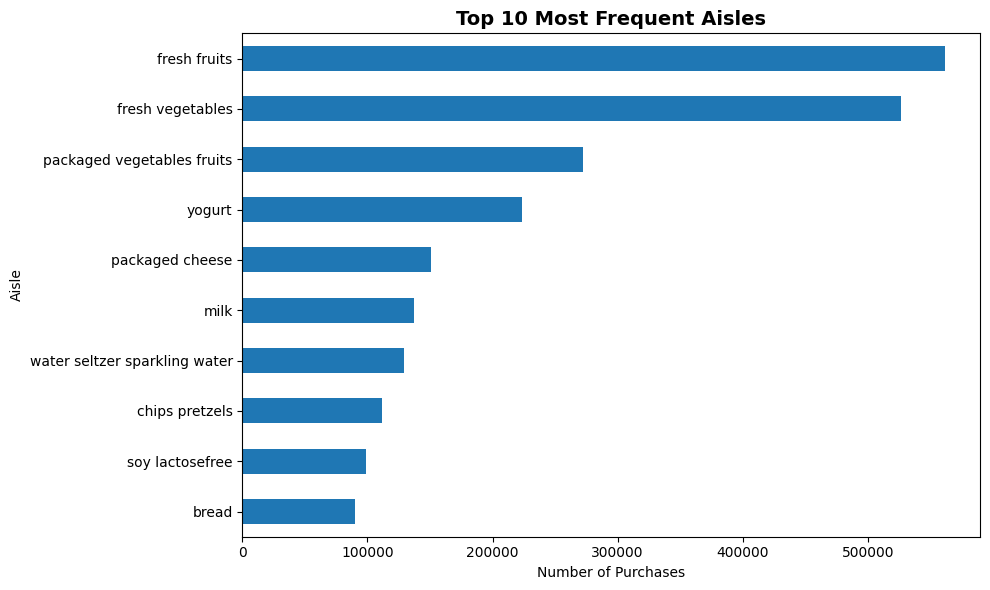

In [18]:
import matplotlib.pyplot as plt


top_aisles = aisle_patterns.head(10)

plt.figure(figsize=(10,6))
top_aisles.sort_values().plot(kind='barh')

plt.title('Top 10 Most Frequent Aisles', fontsize=14, fontweight='bold')
plt.xlabel('Number of Purchases')
plt.ylabel('Aisle')

plt.tight_layout()
plt.show()